In [1]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none")


PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
!pip -q install kagglehub pillow scikit-learn tqdm pandas

In [3]:
import kagglehub
from pathlib import Path

dataset_path = kagglehub.dataset_download("requiemonk/sentinel12-image-pairs-segregated-by-terrain")
dataset_root = Path(dataset_path)

print("Dataset path:", dataset_root)
print("Top-level files/folders:")
for item in sorted(dataset_root.iterdir()):
    print(" -", item.name)


100%|██████████| 2.55G/2.55G [01:10<00:00, 38.6MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/requiemonk/sentinel12-image-pairs-segregated-by-terrain/versions/1
Top-level files/folders:
 - v_2


In [4]:
from pathlib import Path

def show_tree(root, max_depth=5, max_items=160):
    root = Path(root)
    count = 0
    for path in sorted(root.rglob("*")):
        depth = len(path.relative_to(root).parts)
        if depth <= max_depth:
            print("  " * depth + path.name)
            count += 1
            if count >= max_items:
                print("... stopped after", max_items, "items")
                break

show_tree(dataset_root)


  v_2
    agri
      s1
        ROIs1868_summer_s1_59_p10.png
        ROIs1868_summer_s1_59_p100.png
        ROIs1868_summer_s1_59_p1000.png
        ROIs1868_summer_s1_59_p1001.png
        ROIs1868_summer_s1_59_p1002.png
        ROIs1868_summer_s1_59_p1003.png
        ROIs1868_summer_s1_59_p1004.png
        ROIs1868_summer_s1_59_p1005.png
        ROIs1868_summer_s1_59_p1006.png
        ROIs1868_summer_s1_59_p1007.png
        ROIs1868_summer_s1_59_p1008.png
        ROIs1868_summer_s1_59_p1009.png
        ROIs1868_summer_s1_59_p101.png
        ROIs1868_summer_s1_59_p1010.png
        ROIs1868_summer_s1_59_p1011.png
        ROIs1868_summer_s1_59_p1012.png
        ROIs1868_summer_s1_59_p1013.png
        ROIs1868_summer_s1_59_p1014.png
        ROIs1868_summer_s1_59_p1015.png
        ROIs1868_summer_s1_59_p1016.png
        ROIs1868_summer_s1_59_p1017.png
        ROIs1868_summer_s1_59_p1018.png
        ROIs1868_summer_s1_59_p1019.png
        ROIs1868_summer_s1_59_p102.png
        ROIs1868_summ

In [5]:
import os
from collections import Counter
from pathlib import Path

IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}


def normalized_name(name):
    return name.lower().replace("_", "").replace("-", "").replace(" ", "")


def image_files(folder):
    return [p for p in folder.rglob("*") if p.suffix.lower() in IMAGE_EXTS]


all_images = image_files(dataset_root)
print("Total image files:", len(all_images))

print("First 20 image files:")
for path in all_images[:20]:
    print(path.relative_to(dataset_root))

print("\nParent folder counts:")
parent_counts = Counter(str(p.parent.relative_to(dataset_root)) for p in all_images)
for parent, count in parent_counts.most_common(30):
    print(count, parent)


def modality_from_path(path):
    parts = [normalized_name(part) for part in path.relative_to(dataset_root).parts]
    if any(part in {"sar", "s1", "sentinel1"} for part in parts):
        return "radar"
    if any(part in {"opt", "optical", "s2", "sentinel2", "rgb"} for part in parts):
        return "optical"
    return "unknown"


def pair_key(path):
    stem = path.stem
    stem = stem.replace("_s1_", "_sx_")
    stem = stem.replace("_s2_", "_sx_")
    stem = stem.replace("-s1-", "-sx-")
    stem = stem.replace("-s2-", "-sx-")
    return stem


def label_from_path(path):
    parts = path.relative_to(dataset_root).parts
    known_labels = ["agri", "barrenland", "grassland", "urban"]
    for part in parts:
        norm = normalized_name(part)
        if norm in known_labels:
            return norm
    # Fallback: use the folder just above modality folder if possible.
    return parts[-2] if len(parts) >= 2 else "unknown"


records = []
for path in all_images:
    records.append(
        {
            "path": path,
            "modality": modality_from_path(path),
            "label": label_from_path(path),
            "stem": pair_key(path),
        }
    )

print("\nModality counts:", Counter(r["modality"] for r in records))
print("Label counts:", Counter(r["label"] for r in records))

pairs = []

# Strategy 1: exact same filename stem under matching labels.
radar_records = [r for r in records if r["modality"] == "radar"]
optical_records = [r for r in records if r["modality"] == "optical"]
optical_by_label_stem = {(r["label"], r["stem"]): r["path"] for r in optical_records}

for r in radar_records:
    key = (r["label"], r["stem"])
    if key in optical_by_label_stem:
        pairs.append((r["path"], optical_by_label_stem[key], r["label"]))

# Strategy 2: if exact stems fail, pair by sorted order within each label.
if len(pairs) == 0:
    labels = sorted(set(r["label"] for r in records if r["label"] != "unknown"))
    for label in labels:
        radar_paths = sorted(r["path"] for r in radar_records if r["label"] == label)
        optical_paths = sorted(r["path"] for r in optical_records if r["label"] == label)
        for radar_path, optical_path in zip(radar_paths, optical_paths):
            pairs.append((radar_path, optical_path, label))

print("Total pairs:", len(pairs))
print("Class counts:", Counter(label for _, _, label in pairs))
print("First 5 pairs:")
for row in pairs[:5]:
    print(row[0].relative_to(dataset_root), "|", row[1].relative_to(dataset_root), "|", row[2])

if len(pairs) == 0:
    raise RuntimeError("No SAR-optical pairs found. Send Cell 4 and Cell 5 output so we can adapt the parser.")


Total image files: 32000
First 20 image files:
v_2/barrenland/s2/ROIs1970_fall_s2_73_p930.png
v_2/barrenland/s2/ROIs1970_fall_s2_2_p85.png
v_2/barrenland/s2/ROIs1970_fall_s2_124_p907.png
v_2/barrenland/s2/ROIs1970_fall_s2_26_p121.png
v_2/barrenland/s2/ROIs1970_fall_s2_114_p483.png
v_2/barrenland/s2/ROIs1970_fall_s2_2_p522.png
v_2/barrenland/s2/ROIs1970_fall_s2_124_p632.png
v_2/barrenland/s2/ROIs1970_fall_s2_73_p927.png
v_2/barrenland/s2/ROIs1970_fall_s2_71_p839.png
v_2/barrenland/s2/ROIs1970_fall_s2_71_p413.png
v_2/barrenland/s2/ROIs1970_fall_s2_71_p276.png
v_2/barrenland/s2/ROIs1970_fall_s2_71_p284.png
v_2/barrenland/s2/ROIs1970_fall_s2_2_p476.png
v_2/barrenland/s2/ROIs1970_fall_s2_71_p620.png
v_2/barrenland/s2/ROIs1970_fall_s2_114_p135.png
v_2/barrenland/s2/ROIs1970_fall_s2_114_p676.png
v_2/barrenland/s2/ROIs1970_fall_s2_124_p647.png
v_2/barrenland/s2/ROIs1970_fall_s2_124_p717.png
v_2/barrenland/s2/ROIs1970_fall_s2_71_p269.png
v_2/barrenland/s2/ROIs1970_fall_s2_114_p985.png

Parent f

In [6]:
import random
import numpy as np
import pandas as pd
from PIL import Image
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMAGE_SIZE = 128
BATCH_SIZE = 32

classes = sorted(set(label for _, _, label in pairs))
class_to_idx = {name: i for i, name in enumerate(classes)}
idx_to_class = {i: name for name, i in class_to_idx.items()}
NUM_CLASSES = len(classes)

train_pairs, val_pairs = train_test_split(
    pairs,
    test_size=0.2,
    random_state=SEED,
    stratify=[label for _, _, label in pairs],
)

print("Classes:", class_to_idx)
print("Train pairs:", len(train_pairs))
print("Val pairs:", len(val_pairs))


Classes: {'agri': 0, 'barrenland': 1, 'grassland': 2, 'urban': 3}
Train pairs: 12800
Val pairs: 3200


In [7]:
def pil_to_tensor(image, mode):
    image = image.convert(mode)
    image = image.resize((IMAGE_SIZE, IMAGE_SIZE))
    arr = np.array(image).astype("float32") / 255.0

    if arr.ndim == 2:
        arr = arr[None, :, :]
    else:
        arr = np.transpose(arr, (2, 0, 1))

    tensor = torch.from_numpy(arr)
    mean = tensor.mean(dim=(1, 2), keepdim=True)
    std = tensor.std(dim=(1, 2), keepdim=True).clamp_min(1e-6)
    return (tensor - mean) / std


class Sentinel12PairDataset(Dataset):
    def __init__(self, pair_list):
        self.pair_list = pair_list

    def __len__(self):
        return len(self.pair_list)

    def __getitem__(self, idx):
        s1_path, s2_path, label = self.pair_list[idx]

        radar = pil_to_tensor(Image.open(s1_path), "L")      # SAR grayscale, 1 channel
        optical = pil_to_tensor(Image.open(s2_path), "RGB")  # Optical RGB, 3 channels
        y = torch.tensor(class_to_idx[label], dtype=torch.long)

        return radar, optical, y


train_ds = Sentinel12PairDataset(train_pairs)
val_ds = Sentinel12PairDataset(val_pairs)

# num_workers=0 keeps Colab quiet and stable.
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

radar, optical, labels = next(iter(train_loader))
print("Radar:", radar.shape)
print("Optical:", optical.shape)
print("Labels:", labels.shape)


Radar: torch.Size([32, 1, 128, 128])
Optical: torch.Size([32, 3, 128, 128])
Labels: torch.Size([32])


In [8]:
def degrade_optical(optical, mode="clean"):
    if mode == "clean":
        return optical

    x = optical.clone()

    if mode == "noise":
        return x + torch.randn_like(x) * 0.95

    if mode == "heavy_noise":
        return x + torch.randn_like(x) * 1.45

    if mode == "channel_drop":
        mask = (torch.rand(x.shape[0], x.shape[1], 1, 1, device=x.device) > 0.35).float()
        return x * mask

    if mode == "cloud_mask":
        _, _, h, w = x.shape
        mh, mw = int(h * 0.45), int(w * 0.45)
        for i in range(x.shape[0]):
            top = torch.randint(0, h - mh + 1, (1,), device=x.device).item()
            left = torch.randint(0, w - mw + 1, (1,), device=x.device).item()
            x[i, :, top:top+mh, left:left+mw] = 0
        return x

    if mode == "mixed":
        x = x + torch.randn_like(x) * 0.75
        mask = (torch.rand(x.shape[0], x.shape[1], 1, 1, device=x.device) > 0.20).float()
        return x * mask

    raise ValueError(mode)


def random_train_degradation(optical):
    # More noise-heavy than the logit-level fusion variant.
    mode = random.choice([
        "clean",
        "noise",
        "noise",
        "heavy_noise",
        "channel_drop",
        "cloud_mask",
        "mixed",
    ])
    return degrade_optical(optical, mode)


In [9]:
class SmallEncoder(nn.Module):
    def __init__(self, in_channels, feature_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.proj = nn.Linear(128, feature_dim)

    def forward(self, x):
        return self.proj(self.net(x).flatten(1))


def confidence_features(logits):
    probs = torch.softmax(logits, dim=1)
    top2 = torch.topk(probs, k=2, dim=1).values
    max_prob = top2[:, 0:1]
    margin = top2[:, 0:1] - top2[:, 1:2]
    entropy = -(probs * (probs.clamp_min(1e-8).log())).sum(dim=1, keepdim=True)
    entropy = entropy / np.log(NUM_CLASSES)
    return torch.cat([max_prob, margin, entropy], dim=1)


def optical_quality_features(optical):
    # These are simple signal-quality clues. They are not labels.
    mean_abs = optical.abs().mean(dim=(1, 2, 3), keepdim=False).view(-1, 1)
    std = optical.std(dim=(1, 2, 3), keepdim=False).view(-1, 1)
    zero_fraction = (optical.abs() < 1e-6).float().mean(dim=(1, 2, 3), keepdim=False).view(-1, 1)
    high_abs = (optical.abs() > 2.5).float().mean(dim=(1, 2, 3), keepdim=False).view(-1, 1)
    return torch.cat([mean_abs, std, zero_fraction, high_abs], dim=1)


class NoiseAwareReliabilityFusionClassifier(nn.Module):
    def __init__(self, feature_dim=128):
        super().__init__()
        self.radar_encoder = SmallEncoder(1, feature_dim)
        self.optical_encoder = SmallEncoder(3, feature_dim)
        self.radar_head = nn.Linear(feature_dim, NUM_CLASSES)
        self.optical_head = nn.Linear(feature_dim, NUM_CLASSES)

        # feature_dim * 2 + radar confidence 3 + optical confidence 3 + optical quality 4
        self.gate = nn.Sequential(
            nn.Linear(feature_dim * 2 + 10, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.20),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 2),
            nn.Softmax(dim=1),
        )

    def forward(self, radar, optical, return_weights=False, fallback=False):
        radar_features = self.radar_encoder(radar)
        optical_features = self.optical_encoder(optical)

        radar_logits = self.radar_head(radar_features)
        optical_logits = self.optical_head(optical_features)

        radar_conf = confidence_features(radar_logits)
        optical_conf = confidence_features(optical_logits)
        optical_quality = optical_quality_features(optical)

        gate_input = torch.cat(
            [radar_features, optical_features, radar_conf, optical_conf, optical_quality],
            dim=1,
        )
        weights = self.gate(gate_input)

        if fallback:
            radar_max = radar_conf[:, 0:1]
            radar_margin = radar_conf[:, 1:2]
            optical_max = optical_conf[:, 0:1]
            optical_margin = optical_conf[:, 1:2]
            optical_entropy = optical_conf[:, 2:3]
            high_abs = optical_quality[:, 3:4]

            radar_better = (radar_max > optical_max + 0.05) & (radar_margin > optical_margin)
            optical_suspicious = (optical_entropy > 0.70) | (high_abs > 0.12)
            use_radar = (radar_better & optical_suspicious).float()

            fallback_weights = torch.cat(
                [torch.full_like(use_radar, 0.82), torch.full_like(use_radar, 0.18)],
                dim=1,
            )
            weights = use_radar * fallback_weights + (1.0 - use_radar) * weights

        fused_logits = weights[:, 0:1] * radar_logits + weights[:, 1:2] * optical_logits

        if return_weights:
            return fused_logits, weights, radar_logits, optical_logits
        return fused_logits


In [10]:
def train_noise_aware_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0

    for radar, optical, labels in tqdm(loader, leave=False):
        radar = radar.to(DEVICE)
        optical = optical.to(DEVICE)
        labels = labels.to(DEVICE)

        degraded_optical = random_train_degradation(optical)

        optimizer.zero_grad(set_to_none=True)
        fused_logits, weights, radar_logits, optical_logits = model(
            radar,
            degraded_optical,
            return_weights=True,
            fallback=False,
        )

        loss = (
            criterion(fused_logits, labels)
            + 0.45 * criterion(radar_logits, labels)
            + 0.45 * criterion(optical_logits, labels)
        )

        loss.backward()
        optimizer.step()
        total_loss += loss.item() * labels.shape[0]

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate_noise_aware(model, loader, degradation="clean", fallback=False):
    model.eval()
    correct = 0
    total = 0
    all_weights = []

    for radar, optical, labels in tqdm(loader, leave=False):
        radar = radar.to(DEVICE)
        optical = optical.to(DEVICE)
        labels = labels.to(DEVICE)
        optical = degrade_optical(optical, degradation)

        logits, weights, radar_logits, optical_logits = model(
            radar,
            optical,
            return_weights=True,
            fallback=fallback,
        )
        predictions = logits.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.numel()
        all_weights.append(weights.cpu())

    weights = torch.cat(all_weights, dim=0)
    return {
        "accuracy": correct / total,
        "avg_radar_weight": weights[:, 0].mean().item(),
        "avg_optical_weight": weights[:, 1].mean().item(),
    }


In [13]:
noise_aware_model = NoiseAwareReliabilityFusionClassifier().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(noise_aware_model.parameters(), lr=8e-4, weight_decay=1e-4)

best_noise = 0.0
best_state = None

for epoch in range(1, 21):
    train_loss = train_noise_aware_one_epoch(noise_aware_model, train_loader, optimizer, criterion)
    clean = evaluate_noise_aware(noise_aware_model, val_loader, "clean", fallback=True)
    noise = evaluate_noise_aware(noise_aware_model, val_loader, "noise", fallback=True)
    channel = evaluate_noise_aware(noise_aware_model, val_loader, "channel_drop", fallback=True)

    if noise["accuracy"] > best_noise:
        best_noise = noise["accuracy"]
        best_state = {k: v.detach().cpu().clone() for k, v in noise_aware_model.state_dict().items()}

    print(
        f"epoch={epoch} "
        f"loss={train_loss:.4f} "
        f"clean={clean['accuracy']:.4f} "
        f"noise={noise['accuracy']:.4f} "
        f"channel={channel['accuracy']:.4f} "
        f"noise_radar_w={noise['avg_radar_weight']:.3f} "
        f"noise_optical_w={noise['avg_optical_weight']:.3f}"
    )

noise_aware_model.load_state_dict(best_state)
print("Loaded best noise-aware model with noise accuracy:", best_noise)

  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

epoch=1 loss=0.9538 clean=0.7141 noise=0.7372 channel=0.6469 noise_radar_w=0.409 noise_optical_w=0.591


...

  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

epoch=20 loss=0.1884 clean=0.9706 noise=0.3412 channel=0.9516 noise_radar_w=0.228 noise_optical_w=0.772
Loaded best noise-aware model with noise accuracy: 0.9746875


In [14]:
reliability_fusion_probe_results = []

for fallback in [False, True]:
    for setting in ["clean", "noise", "heavy_noise", "channel_drop", "cloud_mask", "mixed"]:
        result = evaluate_noise_aware(noise_aware_model, val_loader, setting, fallback=fallback)
        result["model"] = "reliability_fusion_probe"
        result["setting"] = setting
        result["fallback"] = fallback
        reliability_fusion_probe_results.append(result)
        print("fallback", fallback, setting, result)

reliability_fusion_probe_df = pd.DataFrame(reliability_fusion_probe_results)
display(reliability_fusion_probe_df)

summary = reliability_fusion_probe_df.pivot(index="setting", columns="fallback", values="accuracy")
display(summary)

reliability_fusion_probe_df.to_csv("reliability_fusion_probe_results.csv", index=False)
print("Saved reliability_fusion_probe_results.csv")




  0%|          | 0/100 [00:00<?, ?it/s]

fallback False clean {'accuracy': 0.9403125, 'avg_radar_weight': 0.5513677000999451, 'avg_optical_weight': 0.44863227009773254, 'model': 'reliability_fusion_probe', 'setting': 'clean', 'fallback': False}


  0%|          | 0/100 [00:00<?, ?it/s]

fallback False noise {'accuracy': 0.975, 'avg_radar_weight': 0.45006629824638367, 'avg_optical_weight': 0.549933671951294, 'model': 'reliability_fusion_probe', 'setting': 'noise', 'fallback': False}


  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

fallback True mixed {'accuracy': 0.9578125, 'avg_radar_weight': 0.5720598101615906, 'avg_optical_weight': 0.4279402196407318, 'model': 'reliability_fusion_probe', 'setting': 'mixed', 'fallback': True}


,accuracy,avg_radar_weight,avg_optical_weight,model,setting,fallback
0,0.940312,0.551368,0.448632,reliability_fusion_probe,clean,False
1,0.975000,0.450066,0.549934,reliability_fusion_probe,noise,False
2,0.490312,0.275399,0.724601,reliability_fusion_probe,heavy_noise,False
3,0.919063,0.676426,0.323574,reliability_fusion_probe,channel_drop,False
4,0.943438,0.598450,0.401550,reliability_fusion_probe,cloud_mask,False
5,0.961250,0.565358,0.434642,reliability_fusion_probe,mixed,False
6,0.940000,0.554845,0.445155,reliability_fusion_probe,clean,True
7,0.977812,0.455518,0.544482,reliability_fusion_probe,noise,True
8,0.560312,0.333886,0.666114,reliability_fusion_probe,heavy_noise,True
9,0.919063,0.680718,0.319282,reliability_fusion_probe,channel_drop,True


fallback,False,True
setting,,
channel_drop,0.919063,0.919063
clean,0.940312,0.940000
cloud_mask,0.943438,0.942187
heavy_noise,0.490312,0.560312
mixed,0.961250,0.957812
noise,0.975000,0.977812


Saved reliability_fusion_probe_results.csv


In [16]:
balanced_model = NoiseAwareReliabilityFusionClassifier().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(balanced_model.parameters(), lr=8e-4, weight_decay=1e-4)

best_score = -1.0
best_state = None
best_epoch_summary = None

for epoch in range(1, 16):
    train_loss = train_noise_aware_one_epoch(balanced_model, train_loader, optimizer, criterion)

    clean = evaluate_noise_aware(balanced_model, val_loader, "clean", fallback=False)
    noise = evaluate_noise_aware(balanced_model, val_loader, "noise", fallback=False)
    channel = evaluate_noise_aware(balanced_model, val_loader, "channel_drop", fallback=False)
    cloud = evaluate_noise_aware(balanced_model, val_loader, "cloud_mask", fallback=False)

    balanced_score = (
        clean["accuracy"]
        + noise["accuracy"]
        + channel["accuracy"]
        + cloud["accuracy"]
    ) / 4

    if balanced_score > best_score:
        best_score = balanced_score
        best_state = {k: v.detach().cpu().clone() for k, v in balanced_model.state_dict().items()}
        best_epoch_summary = {
            "epoch": epoch,
            "score": balanced_score,
            "clean": clean,
            "noise": noise,
            "channel_drop": channel,
            "cloud_mask": cloud,
        }

    print(
        f"epoch={epoch} "
        f"loss={train_loss:.4f} "
        f"score={balanced_score:.4f} "
        f"clean={clean['accuracy']:.4f} "
        f"noise={noise['accuracy']:.4f} "
        f"channel={channel['accuracy']:.4f} "
        f"cloud={cloud['accuracy']:.4f} "
        f"noise_radar_w={noise['avg_radar_weight']:.3f} "
        f"noise_optical_w={noise['avg_optical_weight']:.3f}"
    )

balanced_model.load_state_dict(best_state)
print("Best balanced checkpoint:")
print(best_epoch_summary)


  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

epoch=15 loss=0.2231 score=0.8750 clean=0.8562 noise=0.9669 channel=0.8366 cloud=0.8403 noise_radar_w=0.541 noise_optical_w=0.459
Best balanced checkpoint:
{'epoch': 10, 'score': 0.939921875, 'clean': {'accuracy': 0.939375, 'avg_radar_weight': 0.6357142925262451, 'avg_optical_weight': 0.3642856478691101}, 'noise': {'accuracy': 0.960625, 'avg_radar_weight': 0.5374717116355896, 'avg_optical_weight': 0.462528258562088}, 'channel_drop': {'accuracy': 0.925, 'avg_radar_weight': 0.7929989099502563, 'avg_optical_weight': 0.20700107514858246}, 'cloud_mask': {'accuracy': 0.9346875, 'avg_radar_weight': 0.6813082098960876, 'avg_optical_weight': 0.31869179010391235}}


In [17]:
reliability_aware_results = []

for fallback in [False, True]:
    for setting in ["clean", "noise", "heavy_noise", "channel_drop", "cloud_mask", "mixed"]:
        result = evaluate_noise_aware(noise_aware_model, val_loader, setting, fallback=fallback)
        result["model"] = "reliability_aware_fusion_fusion_proposed"
        result["setting"] = setting
        result["fallback"] = fallback
        reliability_aware_results.append(result)
        print("fallback", fallback, setting, result)

reliability_aware_df = pd.DataFrame(reliability_aware_results)
display(reliability_aware_df)

reliability_fusion_probe_df.to_csv("reliability_aware_fusion_results.csv", index=False)
print("Saved reliability_aware_fusion_results.csv")




  0%|          | 0/100 [00:00<?, ?it/s]

fallback False clean {'accuracy': 0.9403125, 'avg_radar_weight': 0.5513677000999451, 'avg_optical_weight': 0.44863227009773254, 'model': 'reliability_aware_fusion_fusion_proposed', 'setting': 'clean', 'fallback': False}


  0%|          | 0/100 [00:00<?, ?it/s]

fallback False noise {'accuracy': 0.978125, 'avg_radar_weight': 0.4497164189815521, 'avg_optical_weight': 0.5502836108207703, 'model': 'reliability_aware_fusion_fusion_proposed', 'setting': 'noise', 'fallback': False}


  0%|          | 0/100 [00:00<?, ?it/s]

...

fallback True cloud_mask {'accuracy': 0.9421875, 'avg_radar_weight': 0.6009843349456787, 'avg_optical_weight': 0.3990156650543213, 'model': 'reliability_aware_fusion_fusion_proposed', 'setting': 'cloud_mask', 'fallback': True}


  0%|          | 0/100 [00:00<?, ?it/s]

fallback True mixed {'accuracy': 0.9584375, 'avg_radar_weight': 0.5730105042457581, 'avg_optical_weight': 0.4269895553588867, 'model': 'reliability_aware_fusion_fusion_proposed', 'setting': 'mixed', 'fallback': True}


,accuracy,avg_radar_weight,avg_optical_weight,model,setting,fallback
0,0.940312,0.551368,0.448632,reliability_aware_fusion_fusion_proposed,clean,False
1,0.978125,0.449716,0.550284,reliability_aware_fusion_fusion_proposed,noise,False
2,0.490938,0.274319,0.725681,reliability_aware_fusion_fusion_proposed,heavy_noise,False
3,0.925625,0.673535,0.326465,reliability_aware_fusion_fusion_proposed,channel_drop,False
4,0.940625,0.597818,0.402182,reliability_aware_fusion_fusion_proposed,cloud_mask,False
5,0.959688,0.566704,0.433296,reliability_aware_fusion_fusion_proposed,mixed,False
6,0.940000,0.554845,0.445155,reliability_aware_fusion_fusion_proposed,clean,True
7,0.973125,0.455892,0.544108,reliability_aware_fusion_fusion_proposed,noise,True
8,0.566562,0.339023,0.660977,reliability_aware_fusion_fusion_proposed,heavy_noise,True
9,0.913125,0.682400,0.317600,reliability_aware_fusion_fusion_proposed,channel_drop,True


Saved reliability_aware_fusion_results.csv


In [20]:

import torch
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from tqdm.auto import tqdm

# Class names matching your dataset
CLASS_NAMES = ['agri', 'barrenland', 'grassland', 'urban']

@torch.no_grad()
def evaluate_with_f1(model, loader, degradation="clean"):
    """Evaluate model and return accuracy, per-class F1, macro F1, and confusion matrix."""
    model.eval()
    all_preds = []
    all_labels = []
    all_weights = []

    for radar, optical, labels in tqdm(loader, leave=False, desc=degradation):
        radar = radar.to(DEVICE)
        optical = optical.to(DEVICE)
        labels = labels.to(DEVICE)

        optical = degrade_optical(optical, degradation)

        logits, weights, radar_logits, optical_logits = model(
            radar, optical, return_weights=True, fallback=False
        )

        preds = logits.argmax(dim=1)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())
        all_weights.append(weights.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    all_weights = np.concatenate(all_weights, axis=0)

    accuracy = (all_preds == all_labels).mean()
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    per_class_f1 = f1_score(all_labels, all_preds, average=None)
    cm = confusion_matrix(all_labels, all_preds)

    return {
        'accuracy': accuracy,
        'macro_f1': macro_f1,
        'per_class_f1': per_class_f1,
        'confusion_matrix': cm,
        'avg_radar_weight': all_weights[:, 0].mean(),
        'avg_optical_weight': all_weights[:, 1].mean(),
    }

print("evaluate_with_f1 defined.")



evaluate_with_f1 defined.


In [21]:
settings = ["clean", "noise", "heavy_noise", "channel_drop", "cloud_mask", "mixed"]

all_results = {}
for setting in settings:
    result = evaluate_with_f1(balanced_model, val_loader, setting)
    all_results[setting] = result
    print(f"\n{'='*50}")
    print(f"Setting: {setting}")
    print(f"Accuracy: {result['accuracy']:.4f}")
    print(f"Macro F1: {result['macro_f1']:.4f}")
    print(f"Per-class F1: {dict(zip(CLASS_NAMES, [f'{v:.4f}' for v in result['per_class_f1']]))}")
    print(f"Radar weight: {result['avg_radar_weight']:.4f}")
    print(f"Optical weight: {result['avg_optical_weight']:.4f}")

print("\nDone. Results stored in all_results dict.")



clean:   0%|          | 0/100 [00:00<?, ?it/s]


Setting: clean
Accuracy: 0.9394
Macro F1: 0.9385
Per-class F1: {'agri': '0.9504', 'barrenland': '0.9436', 'grassland': '0.9057', 'urban': '0.9541'}
Radar weight: 0.6357
Optical weight: 0.3643


noise:   0%|          | 0/100 [00:00<?, ?it/s]


Setting: noise
Accuracy: 0.9603
Macro F1: 0.9599
Per-class F1: {'agri': '0.9317', 'barrenland': '0.9648', 'grassland': '0.9881', 'urban': '0.9553'}
Radar weight: 0.5372
Optical weight: 0.4628


heavy_noise:   0%|          | 0/100 [00:00<?, ?it/s]

...


Setting: channel_drop
Accuracy: 0.9216
Macro F1: 0.9206
Per-class F1: {'agri': '0.9204', 'barrenland': '0.9396', 'grassland': '0.8887', 'urban': '0.9336'}
Radar weight: 0.7942
Optical weight: 0.2058


cloud_mask:   0%|          | 0/100 [00:00<?, ?it/s]


Setting: cloud_mask
Accuracy: 0.9359
Macro F1: 0.9349
Per-class F1: {'agri': '0.9397', 'barrenland': '0.9533', 'grassland': '0.8997', 'urban': '0.9467'}
Radar weight: 0.6812
Optical weight: 0.3188


mixed:   0%|          | 0/100 [00:00<?, ?it/s]


Setting: mixed
Accuracy: 0.9428
Macro F1: 0.9427
Per-class F1: {'agri': '0.9332', 'barrenland': '0.9459', 'grassland': '0.9426', 'urban': '0.9490'}
Radar weight: 0.6671
Optical weight: 0.3329

Done. Results stored in all_results dict.


In [22]:
rows = []
for setting in settings:
    r = all_results[setting]
    row = {
        'Setting': setting,
        'Accuracy': f"{r['accuracy']:.4f}",
        'Macro F1': f"{r['macro_f1']:.4f}",
    }
    for i, cls in enumerate(CLASS_NAMES):
        row[f'F1 ({cls})'] = f"{r['per_class_f1'][i]:.4f}"
    rows.append(row)

f1_df = pd.DataFrame(rows)
display(f1_df)

f1_df.to_csv("table5_perclass_f1.csv", index=False)
print("Saved table5_perclass_f1.csv")



,Setting,Accuracy,Macro F1,F1 (agri),F1 (barrenland),F1 (grassland),F1 (urban)
0,clean,0.9394,0.9385,0.9504,0.9436,0.9057,0.9541
1,noise,0.9603,0.9599,0.9317,0.9648,0.9881,0.9553
2,heavy_noise,0.6634,0.6099,0.2609,0.7826,0.7092,0.6868
3,channel_drop,0.9216,0.9206,0.9204,0.9396,0.8887,0.9336
4,cloud_mask,0.9359,0.9349,0.9397,0.9533,0.8997,0.9467
5,mixed,0.9428,0.9427,0.9332,0.9459,0.9426,0.9490


Saved table5_perclass_f1.csv


In [23]:
for setting in ["clean", "noise", "channel_drop", "cloud_mask"]:
    print(f"\n{'='*50}")
    print(f"Confusion Matrix — {setting}")
    print(f"{'='*50}")
    cm = all_results[setting]['confusion_matrix']
    cm_df = pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES)
    cm_df.index.name = 'True \\ Pred'
    display(cm_df)

    # Also save each
    cm_df.to_csv(f"confusion_matrix_{setting}.csv")
    print(f"Saved confusion_matrix_{setting}.csv")




Confusion Matrix — clean


,agri,barrenland,grassland,urban
True \ Pred,,,,
agri,767,12,1,20
barrenland,7,787,0,6
grassland,38,60,663,39
urban,2,9,0,789


Saved confusion_matrix_clean.csv

Confusion Matrix — noise


,agri,barrenland,grassland,urban
True \ Pred,,,,
agri,702,41,3,54
barrenland,1,794,0,5
grassland,4,4,786,6
urban,0,7,2,791


Saved confusion_matrix_noise.csv

Confusion Matrix — channel_drop


,agri,barrenland,grassland,urban
True \ Pred,,,,
agri,763,9,1,27
barrenland,32,755,2,11
grassland,60,35,643,62
urban,3,8,1,788


Saved confusion_matrix_channel_drop.csv

Confusion Matrix — cloud_mask


,agri,barrenland,grassland,urban
True \ Pred,,,,
agri,764,14,1,21
barrenland,8,786,0,6
grassland,52,41,655,52
urban,2,8,0,790


Saved confusion_matrix_cloud_mask.csv


In [24]:

print("\nDetailed Classification Report (Clean):")
print("="*50)

# Re-gather predictions for clean
all_preds_clean = []
all_labels_clean = []

balanced_model.eval()
with torch.no_grad():
    for radar, optical, labels in val_loader:
        radar = radar.to(DEVICE)
        optical = optical.to(DEVICE)
        logits, _, _, _ = balanced_model(radar, optical, return_weights=True, fallback=False)
        all_preds_clean.append(logits.argmax(dim=1).cpu().numpy())
        all_labels_clean.append(labels.cpu().numpy())

all_preds_clean = np.concatenate(all_preds_clean)
all_labels_clean = np.concatenate(all_labels_clean)

print(classification_report(all_labels_clean, all_preds_clean, target_names=CLASS_NAMES, digits=4))




Detailed Classification Report (Clean):
              precision    recall  f1-score   support

        agri     0.9423    0.9587    0.9504       800
  barrenland     0.9067    0.9838    0.9436       800
   grassland     0.9985    0.8287    0.9057       800
       urban     0.9239    0.9862    0.9541       800

    accuracy                         0.9394      3200
   macro avg     0.9428    0.9394    0.9385      3200
weighted avg     0.9428    0.9394    0.9385      3200



In [25]:

# Combined summary CSV
summary_rows = []
for setting in settings:
    r = all_results[setting]
    row = {
        'setting': setting,
        'accuracy': r['accuracy'],
        'macro_f1': r['macro_f1'],
        'radar_weight': r['avg_radar_weight'],
        'optical_weight': r['avg_optical_weight'],
    }
    for i, cls in enumerate(CLASS_NAMES):
        row[f'f1_{cls}'] = r['per_class_f1'][i]
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv("reliability_aware_fusion_full_metrics.csv", index=False)
display(summary_df)
print("\nSaved reliability_aware_fusion_full_metrics.csv")
print("\n" + "="*60)
print("DONE. Send me these files:")
print("  1. table5_perclass_f1.csv")
print("  2. confusion_matrix_clean.csv")
print("  3. confusion_matrix_noise.csv")
print("  4. confusion_matrix_channel_drop.csv")
print("  5. confusion_matrix_cloud_mask.csv")
print("  6. reliability_aware_fusion_full_metrics.csv")
print("  7. Copy the Cell 5 classification report text")
print("="*60)



,setting,accuracy,macro_f1,radar_weight,optical_weight,f1_agri,f1_barrenland,f1_grassland,f1_urban
0,clean,0.939375,0.938467,0.635714,0.364286,0.950434,0.943645,0.905738,0.954051
1,noise,0.960313,0.959947,0.537195,0.462805,0.931652,0.964763,0.988058,0.955314
2,heavy_noise,0.663438,0.609883,0.388554,0.611446,0.260870,0.782609,0.709220,0.686836
3,channel_drop,0.921562,0.920602,0.794204,0.205796,0.920386,0.939639,0.888735,0.933649
4,cloud_mask,0.935937,0.934859,0.681202,0.318798,0.939729,0.953305,0.899725,0.946675
5,mixed,0.942813,0.942680,0.667118,0.332882,0.933164,0.945897,0.942650,0.949010



Saved reliability_aware_fusion_full_metrics.csv

DONE. Send me these files:
  1. table5_perclass_f1.csv
  2. confusion_matrix_clean.csv
  3. confusion_matrix_noise.csv
  4. confusion_matrix_channel_drop.csv
  5. confusion_matrix_cloud_mask.csv
  6. reliability_aware_fusion_full_metrics.csv
  7. Copy the Cell 5 classification report text


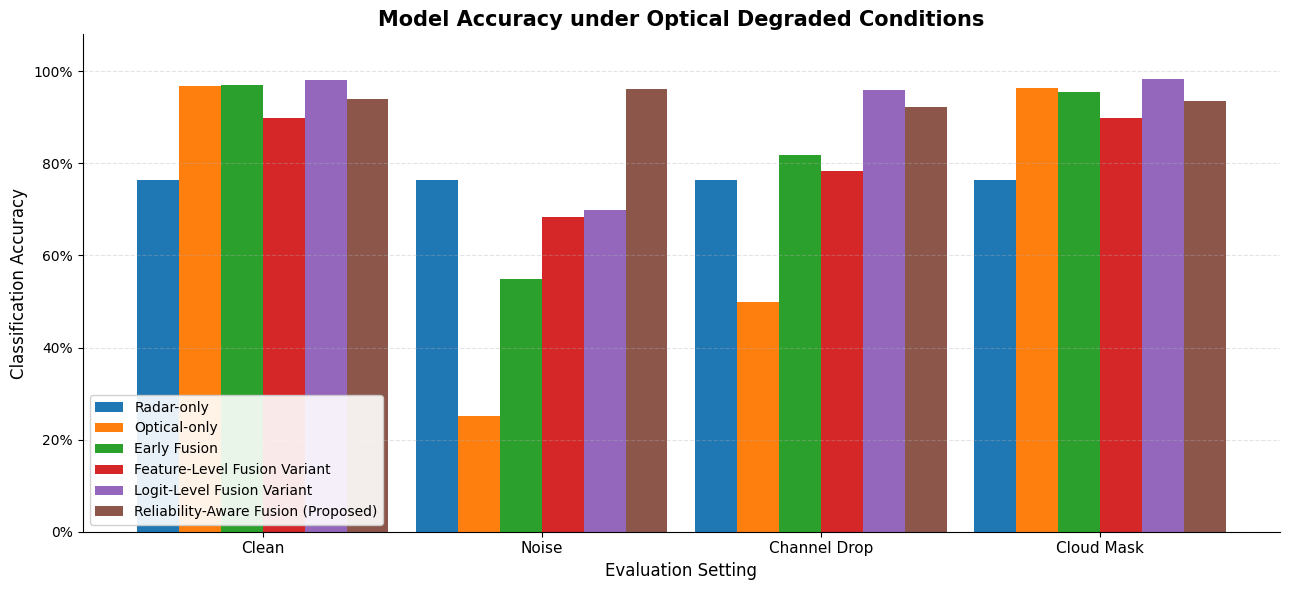

Saved: figure_results_comparison.png
Proposed row used: [np.float64(0.9394), np.float64(0.9603), np.float64(0.9216), np.float64(0.9359)]


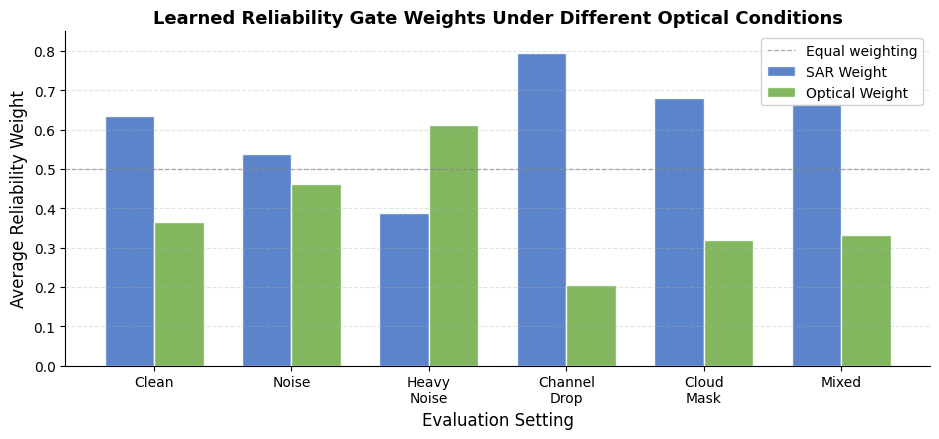

Saved: figure_gate_weights.png


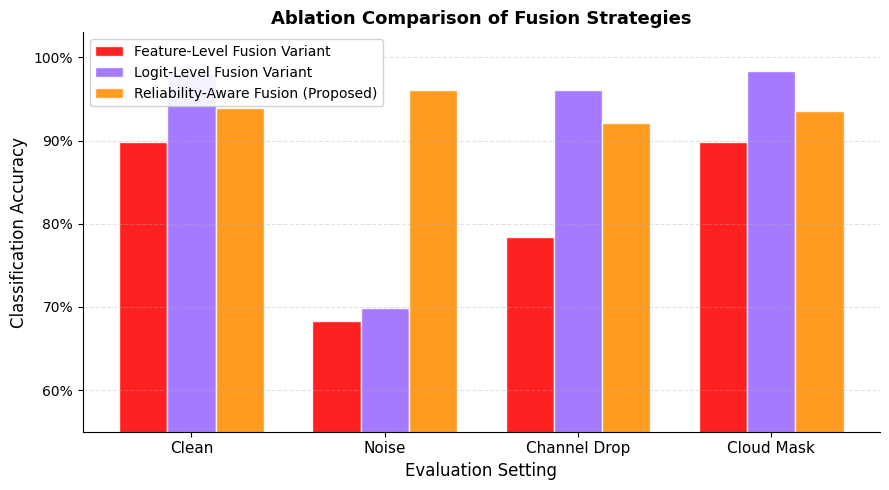

Saved: figure_ablation_fusion_strategies.png


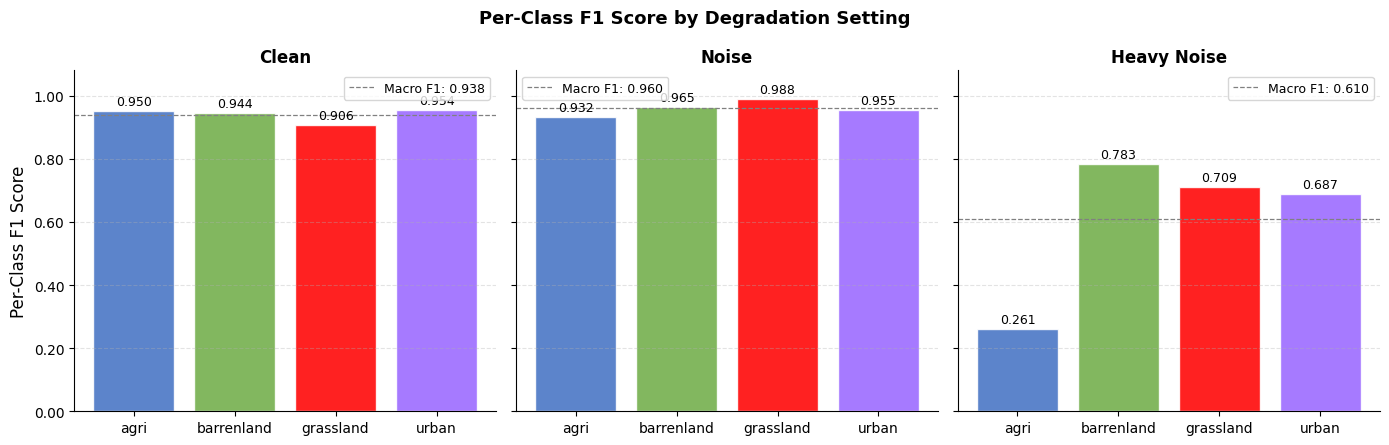

Saved: figure_per_class_f1.png


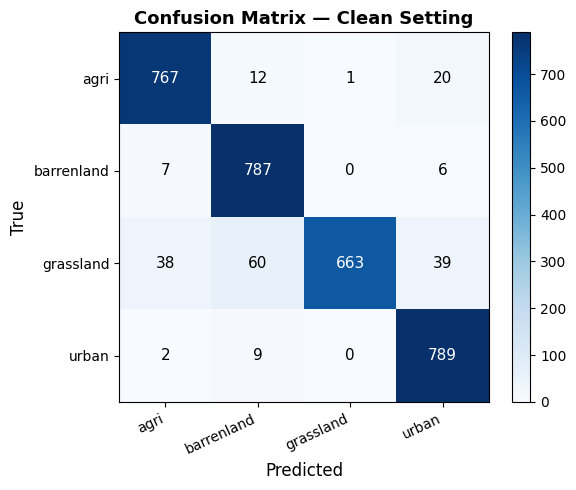

Saved: figure_per_class_f1.png and figure_confusion_matrix_clean.png


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import ConfusionMatrixDisplay

OUT_DIR = Path("paper_figures")
OUT_DIR.mkdir(exist_ok=True)

# -----------------------------
# Shared style helper
# -----------------------------
def clean_axes(ax, full_box=True):
    """
    full_box=True keeps top/right borders visible for consistency.
    full_box=False removes top/right borders for cleaner matrix-style figures.
    """
    if full_box:
        for side in ["top", "right", "left", "bottom"]:
            ax.spines[side].set_visible(True)
            ax.spines[side].set_linewidth(1.0)
    else:
        for side in ["top", "right", "left", "bottom"]:
            ax.spines[side].set_visible(False)

    ax.grid(axis="y", linestyle="--", alpha=0.35)




# -----------------------------
# Figure 1: Accuracy comparison
# -----------------------------
settings_plot = ["Clean", "Noise", "Channel Drop", "Cloud Mask"]
setting_keys  = ['clean', 'noise', 'channel_drop', 'cloud_mask']

models = {
    "Radar-only":                          [0.763, 0.763, 0.763, 0.763],
    "Optical-only":                        [0.968, 0.251, 0.499, 0.963],
    "Early Fusion":                        [0.970, 0.549, 0.817, 0.955],
    "Feature-Level Fusion Variant":        [0.898, 0.683, 0.784, 0.898],
    "Logit-Level Fusion Variant":          [0.981, 0.698, 0.960, 0.983],

    "Reliability-Aware Fusion (Proposed)": [all_results[k]["accuracy"] for k in setting_keys],
}

x     = np.arange(len(settings_plot))
width = 0.15

fig, ax = plt.subplots(figsize=(13, 6))
for i, (label, values) in enumerate(models.items()):
    ax.bar(x + (i - 2.5) * width, values, width, label=label)

ax.set_title("Model Accuracy under Optical Degraded Conditions", fontsize=15, fontweight="bold")
ax.set_xlabel("Evaluation Setting", fontsize=12)
ax.set_ylabel("Classification Accuracy", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(settings_plot, fontsize=11)
ax.set_ylim(0, 1.08)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend(fontsize=10, loc="lower left", framealpha=0.9)
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("figure_results_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: figure_results_comparison.png")
print("Proposed row used:", [round(all_results[k]["accuracy"], 4) for k in setting_keys])


# -----------------------------
# Figure 2: Ablation comparison
# -----------------------------
settings_gate = ['Clean', 'Noise', 'Heavy\nNoise', 'Channel\nDrop', 'Cloud\nMask', 'Mixed']
gate_keys     = ['clean', 'noise', 'heavy_noise', 'channel_drop', 'cloud_mask', 'mixed']

# Read live from all_results
radar_w   = [all_results[k]['avg_radar_weight']   for k in gate_keys]
optical_w = [all_results[k]['avg_optical_weight'] for k in gate_keys]

x_g   = np.arange(len(settings_gate))
w_bar = 0.36

fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.bar(x_g - w_bar/2, radar_w,   w_bar, label='SAR Weight',
       color='#4472C4', alpha=0.87, edgecolor='white')
ax.bar(x_g + w_bar/2, optical_w, w_bar, label='Optical Weight',
       color='#70AD47', alpha=0.87, edgecolor='white')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.9,
           alpha=0.65, label='Equal weighting')

ax.set_xlabel('Evaluation Setting', fontsize=12)
ax.set_ylabel('Average Reliability Weight', fontsize=12)
ax.set_title('Learned Reliability Gate Weights Under Different Optical Conditions',
             fontsize=13, fontweight='bold')
ax.set_xticks(x_g)
ax.set_xticklabels(settings_gate, fontsize=10)
ax.set_ylim(0, 0.85)
ax.legend(fontsize=10, loc='upper right', framealpha=0.9)
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figure_gate_weights.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figure_gate_weights.png")


# -----------------------------
# Figure 3: Reliability gate weights
# -----------------------------
settings_prog = ['Clean', 'Noise', 'Channel Drop', 'Cloud Mask']
prog_keys     = ['clean', 'noise', 'channel_drop', 'cloud_mask']

feature_level_fusion_acc = [0.8984, 0.6825, 0.7841, 0.8984]
logit_level_fusion_acc = [0.9806, 0.6984, 0.9603, 0.9834]
reliability_aware_fusion_acc = [all_results[k]['accuracy'] for k in prog_keys]

x_p = np.arange(len(settings_prog))
w_p = 0.25
colors_p = ['#FF0000', '#9966FF', '#FF8C00']
labels_p = [
    'Feature-Level Fusion Variant',
    'Logit-Level Fusion Variant',
    'Reliability-Aware Fusion (Proposed)',
]

fig, ax = plt.subplots(figsize=(9, 5))
for i, (data, label, color) in enumerate(zip(
        [feature_level_fusion_acc, logit_level_fusion_acc, reliability_aware_fusion_acc],
        labels_p,
        colors_p,
)):
    ax.bar(x_p + (i - 1) * w_p, data, w_p,
           label=label, color=color, alpha=0.87, edgecolor='white')

ax.set_xlabel('Evaluation Setting', fontsize=12)
ax.set_ylabel('Classification Accuracy', fontsize=12)
ax.set_title('Ablation Comparison of Fusion Strategies',
             fontsize=13, fontweight='bold')
ax.set_xticks(x_p)
ax.set_xticklabels(settings_prog, fontsize=11)
ax.set_ylim(0.55, 1.03)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend(fontsize=10, framealpha=0.9)
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figure_ablation_fusion_strategies.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figure_ablation_fusion_strategies.png")



# -----------------------------
# Figure 4: Per-class F1 scores
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)
bar_colors = ['#4472C4', '#70AD47', '#FF0000', '#9966FF']

for ax, setting_key, setting_label in zip(
        axes,
        ['clean', 'noise', 'heavy_noise'],
        ['Clean', 'Noise', 'Heavy Noise']):
    f1 = all_results[setting_key]['per_class_f1']
    bars = ax.bar(CLASS_NAMES, f1, color=bar_colors, alpha=0.87, edgecolor='white')
    ax.axhline(f1.mean(), color='gray', linestyle='--',
               linewidth=0.9, label=f'Macro F1: {f1.mean():.3f}')
    ax.set_title(setting_label, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.08)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2f}'))
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.35)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for bar, val in zip(bars, f1):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

axes[0].set_ylabel('Per-Class F1 Score', fontsize=12)
fig.suptitle('Per-Class F1 Score by Degradation Setting',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figure_per_class_f1.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figure_per_class_f1.png")

# Confusion matrix (clean only)
cm = all_results['clean']['confusion_matrix']
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels(CLASS_NAMES, rotation=25, ha='right')
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title('Confusion Matrix — Clean Setting', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.046)
for i in range(4):
    for j in range(4):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=11,
                color='white' if cm[i, j] > cm.max() * 0.5 else 'black')
plt.tight_layout()
plt.savefig('figure_confusion_matrix_clean.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figure_per_class_f1.png and figure_confusion_matrix_clean.png")



In [27]:
torch.save(balanced_model.state_dict(), "balanced_model_seed2026.pt")

In [28]:
balanced_model = NoiseAwareReliabilityFusionClassifier().to(DEVICE)
balanced_model.load_state_dict(torch.load("balanced_model_seed2026.pt", map_location=DEVICE))
balanced_model.eval()

NoiseAwareReliabilityFusionClassifier(
  (radar_encoder): SmallEncoder(
    (net): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU(inplace=True)
      (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): ReLU(inplace=True)
      (11): AdaptiveAvgPool2d(output_size=1)
    )
    (proj): Linear(in_features=128, out_features=128, bias=True)
  )
  (optical_encode

In [29]:
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True, warn_only=True)